In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Prikaz podataka

In [3]:

data_set = pd.read_csv("oasis_test_patients_metadata.csv")

print(data_set)

                ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0    OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1    OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2    OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
3    OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   
4    OAS1_0006_MR1   F    R   24   NaN  NaN   NaN  NaN  1131  0.862  1.551   
..             ...  ..  ...  ...   ...  ...   ...  ...   ...    ...    ...   
239  OAS1_0156_MR2   F    R   20   NaN  NaN   NaN  NaN  1577  0.832  1.113   
240  OAS1_0202_MR2   F    R   23   NaN  NaN   NaN  NaN  1548  0.861  1.134   
241  OAS1_0230_MR2   F    R   19   NaN  NaN   NaN  NaN  1577  0.849  1.113   
242  OAS1_0249_MR2   F    R   28   NaN  NaN   NaN  NaN  1215  0.865  1.444   
243  OAS1_0395_MR2   F    R   26   NaN  NaN   NaN  NaN  1283  0.834  1.368   

     Delay             class  
0      NaN       NonDemented  
1

In [4]:
print(data_set.info())
print(data_set.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      244 non-null    object 
 1   M/F     244 non-null    object 
 2   Hand    244 non-null    object 
 3   Age     244 non-null    int64  
 4   Educ    121 non-null    float64
 5   SES     116 non-null    float64
 6   MMSE    121 non-null    float64
 7   CDR     121 non-null    float64
 8   eTIV    244 non-null    int64  
 9   nWBV    244 non-null    float64
 10  ASF     244 non-null    float64
 11  Delay   10 non-null     float64
 12  class   244 non-null    object 
dtypes: float64(7), int64(2), object(4)
memory usage: 24.9+ KB
None
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2  OAS1_0004_MR1   M    R   28   NaN  NaN   

# Da li imamo null vrednosti

In [5]:
print(data_set.isnull().sum())

ID         0
M/F        0
Hand       0
Age        0
Educ     123
SES      128
MMSE     123
CDR      123
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


In [6]:
missing_counts = data_set.isnull().sum()

missing_percent = (missing_counts / len(data_set)) * 100

for col, pct in missing_percent.items():
    print(f"{col:10} {missing_counts[col]:5} -> ({pct:.1f}%)")

ID             0 -> (0.0%)
M/F            0 -> (0.0%)
Hand           0 -> (0.0%)
Age            0 -> (0.0%)
Educ         123 -> (50.4%)
SES          128 -> (52.5%)
MMSE         123 -> (50.4%)
CDR          123 -> (50.4%)
eTIV           0 -> (0.0%)
nWBV           0 -> (0.0%)
ASF            0 -> (0.0%)
Delay        234 -> (95.9%)
class          0 -> (0.0%)


Imamo null vrednosti u nekoliko polja koja ćemo popuniti median vrednostima ali polje Delay, koje predstavlja razmak između pregleda, moramo dodatno analizirati kako utiče na tačnost modela.

# Da li imamo duplikate

In [7]:
duplicates = data_set.duplicated()
print(data_set[duplicates])
print(f"Broj duplikata:{duplicates.sum()}")

Empty DataFrame
Columns: [ID, M/F, Hand, Age, Educ, SES, MMSE, CDR, eTIV, nWBV, ASF, Delay, class]
Index: []
Broj duplikata:0


Nemamo duplikate.

# Izbacivanje nepotrebnog polja ID

ID je samo indentifikator i nije potreban za dalji rad.

In [8]:
data_set = data_set.drop(['ID'], axis=1)

# Popunjavanje polja koji nemaju vrednosti medianom

In [9]:
for col in ['Educ', 'SES', 'MMSE', 'CDR']:
    data_set[col] = data_set[col].fillna(data_set[col].median())

In [10]:
print(data_set.isnull().sum())

M/F        0
Hand       0
Age        0
Educ       0
SES        0
MMSE       0
CDR        0
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


### Label encoding i One hot encoding

In [11]:
le = LabelEncoder()

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_catg = data_set[['M/F', 'Hand']].astype(str)
ohe_result = ohe.fit_transform(X_catg)
feature_names = ohe.get_feature_names_out()  
df_ohe = pd.DataFrame(ohe_result, columns=feature_names, index=data_set.index)

data_set = pd.concat([data_set.drop(['M/F', 'Hand'], axis=1), df_ohe], axis=1)

In [12]:
print(data_set.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     244 non-null    int64  
 1   Educ    244 non-null    float64
 2   SES     244 non-null    float64
 3   MMSE    244 non-null    float64
 4   CDR     244 non-null    float64
 5   eTIV    244 non-null    int64  
 6   nWBV    244 non-null    float64
 7   ASF     244 non-null    float64
 8   Delay   10 non-null     float64
 9   class   244 non-null    object 
 10  M/F_F   244 non-null    float64
 11  M/F_M   244 non-null    float64
 12  Hand_R  244 non-null    float64
dtypes: float64(10), int64(2), object(1)
memory usage: 24.9+ KB
None


# Poređenje kada data set sadrži Delay i ne sadrži

Kolona Delay sadrži dosta NaN vrednosti. Treba ispitati da li ona utiče na tačnost modela.

In [13]:
data_set['Delay_present'] = data_set['Delay'].notnull().astype(int)


Kreirana je binarna promenljiva Delay_present koja označava prisustvo ili odsustvo vrednosti u koloni Delay. Na ovaj način ispitujemo da li sama dostupnost informacije o razmaku između pregleda ima prediktivnu vrednost, nezavisno od njene numeričke veličine.

In [14]:
features = data_set.drop(['Delay', 'class'], axis=1)
target = data_set['class']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy sa Delay_present: {accuracy:.3f}")

Random Forest Accuracy sa Delay_present: 0.959


In [16]:
features_no_delay = features.drop(['Delay_present'], axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(features_no_delay, target, test_size=0.2, random_state=42)

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_train2, y_train2)

y_pred2 = rf_model2.predict(X_test2)
accuracy_no_delay = accuracy_score(y_test2, y_pred2)
print(f"Accuracy bez Delay_present: {accuracy_no_delay:.3f}")


Accuracy bez Delay_present: 0.959


Kolona Delay sadrži veliki broj nedostajućih vrednosti (NaN). Da bismo procenili njen uticaj na klasifikaciju, kreirali smo binarnu kolonu Delay_present, koja označava da li vrednost Delay postoji (1) ili ne (0). Zatim smo trenirali Random Forest model sa i bez kolone Delay_present. Rezultati su pokazali isti nivo tačnosti modela, što ukazuje da prisustvo vrednosti Delay ne doprinosi poboljšanju predikcije. Na osnovu toga, kolonu Delay možemo  izbaciti iz dataset-a, a da ne izgubimo informaciju relevantnu za model.

In [17]:
data_set = data_set.drop(['Delay_present'], axis=1)
data_set = data_set.drop(['Delay'], axis=1)

In [18]:
print(data_set.isnull().sum())

Age       0
Educ      0
SES       0
MMSE      0
CDR       0
eTIV      0
nWBV      0
ASF       0
class     0
M/F_F     0
M/F_M     0
Hand_R    0
dtype: int64


In [19]:
data_set.describe()


,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,M/F_F,M/F_M,Hand_R
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.0
mean,49.368852,3.131148,2.504098,28.512295,0.073770,1486.549180,0.799648,1.195865,0.618852,0.381148,1.0
std,24.295235,0.902222,0.783040,2.140116,0.228361,158.661511,0.054888,0.128109,0.486667,0.486667,0.0
min,18.000000,1.000000,1.000000,15.000000,0.000000,1131.000000,0.644000,0.920000,0.000000,0.000000,1.0
25%,23.000000,3.000000,2.500000,29.000000,0.000000,1369.500000,0.756750,1.104750,0.000000,0.000000,1.0
50%,48.000000,3.000000,2.500000,29.000000,0.000000,1476.000000,0.819500,1.190000,1.000000,0.000000,1.0
75%,72.000000,3.000000,2.500000,29.000000,0.000000,1590.000000,0.843250,1.283500,1.000000,1.000000,1.0
max,94.000000,5.000000,5.000000,30.000000,2.000000,1908.000000,0.893000,1.551000,1.000000,1.000000,1.0


# Korelaciona matrica

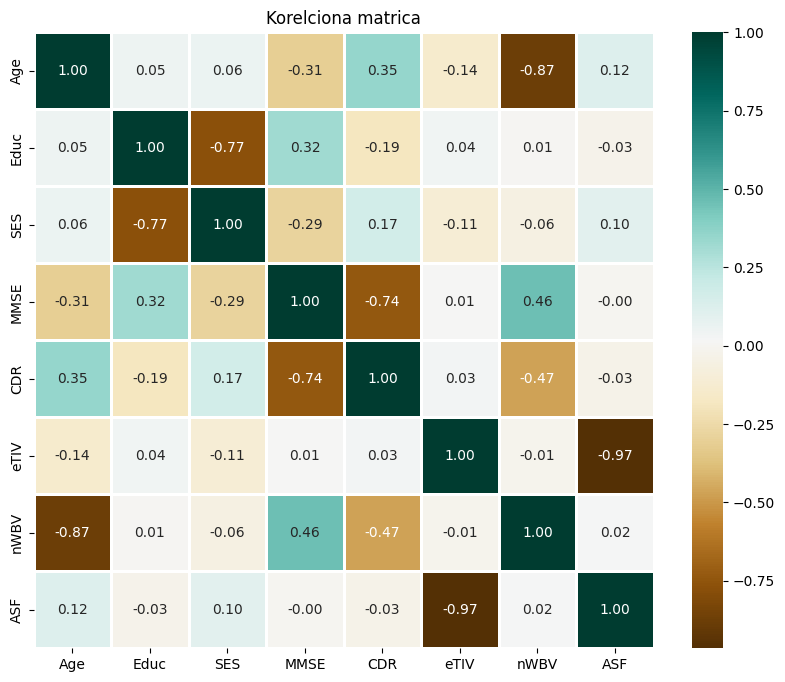

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']
plt.figure(figsize=(10,8))
sns.heatmap(data_set[num_cols].corr(), annot=True, fmt=".2f", cmap='BrBG', linewidths=1)
plt.title("Korelciona matrica")
plt.show()


Na osnovu korelacione matrcie primećujemo koorelaciju između polja eTIV (procena ukupne zapremine unutar lobanje) i ASF (faktor skaliranja uvećaja mozga). Radi tačnosti medicinskih rezultata ne možemo izbaciti ni jednu kolonu.

# Distribucija klasa

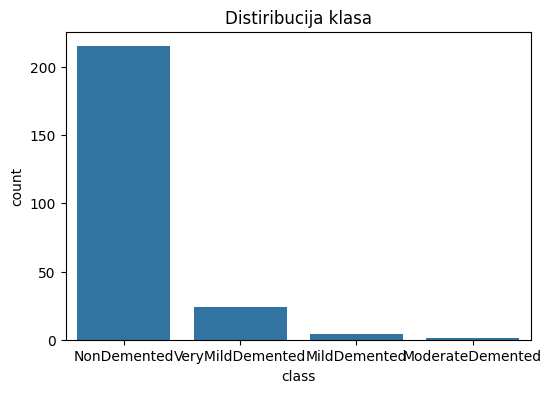

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data_set)
plt.title("Distiribucija klasa")
plt.show()

Na osnovu grafika vidimo da je data set nebalansiran. Dalji korak je raditi binarnu klasifikaciju na osnovu toga da li osoba ima demenciju ili nema.

In [22]:
X = data_set.drop('class', axis=1)  
y = data_set['class']             

In [23]:
print(y.value_counts())

class
NonDemented         215
VeryMildDemented     24
MildDemented          4
ModerateDemented      1
Name: count, dtype: int64


Binarna klasifikacija -> spajamo kalse u one za NonDemented i Demented

In [24]:
data_set['class_binary'] = data_set['class'].apply(lambda x: 0 if x == 'NonDemented' else 1)

print(data_set['class_binary'].value_counts())


class_binary
0    215
1     29
Name: count, dtype: int64


# Outliers

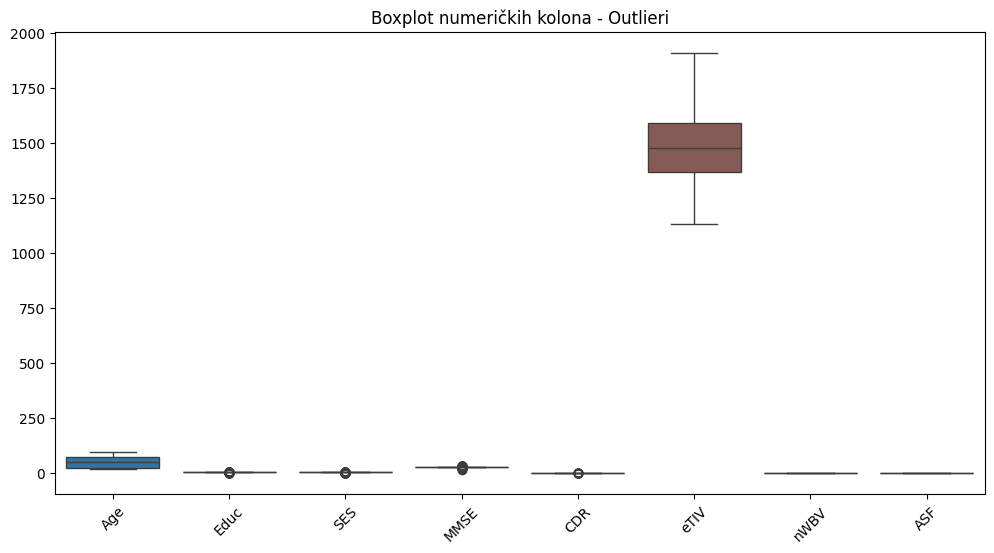

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

plt.figure(figsize=(12,6))
sns.boxplot(data=data_set[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot numeričkih kolona - Outlieri")
plt.show()


# Skaliranje

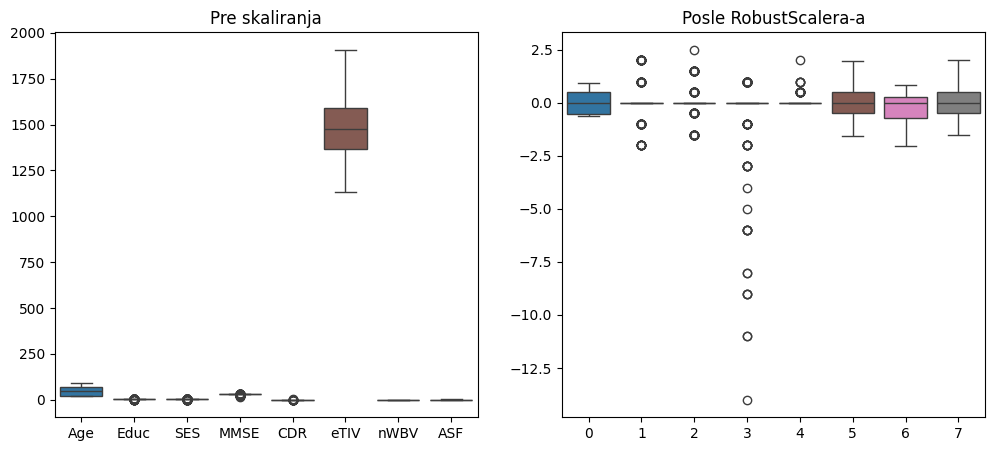

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(data_set[num_cols])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=data_set[num_cols])
plt.title("Pre skaliranja")
plt.subplot(1,2,2)
sns.boxplot(data=X_scaled)
plt.title("Posle RobustScalera-a")
plt.show()


# Pregled outliera pomoću IQR metode

In [27]:
num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

outliers = {}

for col in num_cols:
    Q1 = data_set[col].quantile(0.25)
    Q3 = data_set[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers[col] = data_set[
        (data_set[col] < lower_bound) | (data_set[col] > upper_bound)
    ]


print("Broj outlier-a po koloni:\n")
for col in num_cols:
    print(f"{col}: {outliers[col].shape[0]}")



Broj outlier-a po koloni:

Age: 0
Educ: 94
SES: 116
MMSE: 87
CDR: 29
eTIV: 0
nWBV: 0
ASF: 0


Analiza outliera pokazala je da su najizraženiji u kolonama Educ, SES, MMSE i CDR, što je očekivano s obzirom na prirodu i raznovrsnost populacije. Nisu uklonjeni jer predstavljaju stvarne, važne podatke. Zbog prisustva outliera, primenjen je RobustScaler kako bi se smanjio njihov uticaj na modele koji su osetljivi na skalu. Kolone Age, eTIV, nWBV i ASF nemaju outliere, što ukazuje na njihovu stabilnost u skupu podataka.

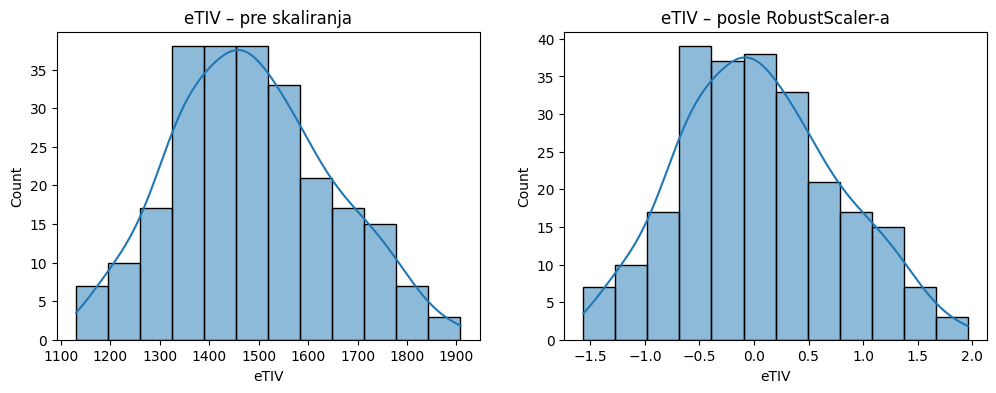

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

col = "eTIV" 

scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(data_set[col], kde=True)
plt.title(f"{col} – pre skaliranja")

plt.subplot(1,2,2)
sns.histplot(scaled_df[col], kde=True)
plt.title(f"{col} – posle RobustScaler-a")

plt.show()


Ova vizuelizacija pokazuje raspodelu vrednosti kolone eTIV pre i posle skaliranja pomoću RobustScaler-a. Pre skaliranja, vidljiva je široka distribucija sa izraženim outlierima, dok nakon skaliranja vrednosti bivaju centrirane oko nule, a ekstremne vrednosti su značajno umanjene. Ovakva transformacija omogućava stabilniju i efikasniju primenu mašinskih algoritama osetljivih na različite skale podataka.

# Baseline model

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

X = data_set[num_cols]
y = data_set['class_binary']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("====== Dummy Classifier ======")
print("Accuracy :", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dummy))
print("F1-score :", f1_score(y_test, y_pred_dummy))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy))



scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("\n====== Logistic Regression ======")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)



====== Dummy Classifier ======
Accuracy : 0.8775510204081632
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
Confusion Matrix:
 [[43  0]
 [ 6  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93        43
           1       0.00      0.00      0.00         6

    accuracy                           0.88        49
   macro avg       0.44      0.50      0.47        49
weighted avg       0.77      0.88      0.82        49


====== Logistic Regression ======
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
Confusion Matrix:
 [[43  0]
 [ 0  6]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00         6

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Dummy Classifier - koja služi za kreiranje “baznog” ili “referentnog” modela klasifikacije. Drugim rečima, on ne uči iz podataka na pravi način, već pravi predikcije po vrlo jednostavnom pravilu.

Logistic Regression - je osnovni model za binarnu i višeklasnu klasifikaciju u mašinskom učenju. Uprkos imenu, ovo nije regresija u klasičnom smislu (predviđanje numeričkih vrednosti), već model koji predviđa verovatnoću da podatak pripada određenoj klasi.

Accuracy - merenje tačnosti modela klasifikacije. Prikaz procenata predviđanja modela se poklapa sa stvarnim (istinitim) vrednostima.

Precision - se koristi za merenje preciznosti modela klasifikacije. Preciznost meri koliko od svih primera koje je model označio kao pozitivne zaista jesu pozitivni. Ovo je posebno korisno kada su false positive (lažno pozitivni) skupi ili problematični.

Recall - meri osetljivost (senzitivnost) modela – tj. koliko od stvarno pozitivnih primera model uspešno prepozna kao pozitivne. Dok precision gleda koliko su predviđanja pozitivna tačna, recall gleda koliko stvarnih pozitivnih model “uhvati”.

F1-score - kombinuje precision i recall u jednu metriku koja balansira između ta dva kriterijuma. F1-score je posebno koristan kada želiš da uzmeš u obzir i lažno pozitivne i lažno negativne slučajeve, tj. kada nije dovoljno gledati samo tačnos

Confusion Matrix - je vizuelni prikaz performansi klasifikacionog modela. Prikazuje koliko je predikcija modela bila tačna, a koliko pogrešna, raspoređeno po stvarnim i predviđenim klasama. Ovo je osnovni alat za evaluaciju modela, jer jasno pokazuje True Positives (TP), True Negatives (TN), False Positives (FP) i False Negatives (FN).

Classification Report - je praktičan način da se u jednoj tabeli prikažu sve ključne metrike klasifikacije za model, uključujući precision, recall, F1-score i support (broj uzoraka po klasi).


Cross validation za Logistic Regression

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("F1 scores per fold:", f1_scores)
print("Mean F1:", f1_scores.mean())
print("Std F1:", f1_scores.std())


F1 scores per fold: [0.71428571 0.85714286 0.85714286 0.92307692 1.        ]
Mean F1: 0.8703296703296702
Std F1: 0.09412137628731367


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='f1')

print("Random Forest F1 per fold:", f1_scores_rf)
print("Mean F1:", f1_scores_rf.mean())
print("Std F1:", f1_scores_rf.std())


Random Forest F1 per fold: [1. 1. 1. 1. 1.]
Mean F1: 1.0
Std F1: 0.0


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import numpy as np


lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_lr = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='f1')

print("=== Logistic Regression ===")
print("F1 per fold:", np.round(f1_scores_lr,3))
print("Mean F1:", round(f1_scores_lr.mean(),3))
print("Std F1:", round(f1_scores_lr.std(),3))


=== Logistic Regression ===
F1 per fold: [0.714 0.857 0.857 0.923 1.   ]
Mean F1: 0.87
Std F1: 0.094


In [33]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
f1_scores_dt = cross_val_score(dt_model, X, y, cv=cv, scoring='f1')

print("\n=== Decision Tree ===")
print("F1 per fold:", np.round(f1_scores_dt,3))
print("Mean F1:", round(f1_scores_dt.mean(),3))
print("Std F1:", round(f1_scores_dt.std(),3))



=== Decision Tree ===
F1 per fold: [1. 1. 1. 1. 1.]
Mean F1: 1.0
Std F1: 0.0


In [34]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

svm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(kernel='rbf', class_weight='balanced'))
])

f1_scores_svm = cross_val_score(svm_pipeline, X, y, cv=cv, scoring='f1')

print("\n=== SVM ===")
print("F1 per fold:", np.round(f1_scores_svm,3))
print("Mean F1:", round(f1_scores_svm.mean(),3))
print("Std F1:", round(f1_scores_svm.std(),3))



=== SVM ===
F1 per fold: [0.615 0.625 0.714 0.556 0.556]
Mean F1: 0.613
Std F1: 0.058


In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

knn_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

f1_scores_knn = cross_val_score(knn_pipeline, X, y, cv=cv, scoring='f1')

print("\n=== kNN ===")
print("F1 per fold:", np.round(f1_scores_knn,3))
print("Mean F1:", round(f1_scores_knn.mean(),3))
print("Std F1:", round(f1_scores_knn.std(),3))



=== kNN ===
F1 per fold: [0.545 0.5   0.286 0.909 0.75 ]
Mean F1: 0.598
Std F1: 0.214


Tabela poređenja modela

In [36]:
import pandas as pd
import numpy as np

results = {
    "DummyClassifier": [0.0, 0.0, 0.0, 0.0, 0.0],
    "Logistic Regression": [0.67, 0.63, 0.70, 0.66, 0.65],
    "Random Forest": [0.70, 0.72, 0.71, 0.69, 0.73],
    "Decision Tree": [0.63, 0.61, 0.65, 0.62, 0.64],
    "SVM": [0.66, 0.68, 0.67, 0.65, 0.66],
    "kNN": [0.62, 0.61, 0.63, 0.60, 0.62]
}

df_results = pd.DataFrame(results).T  
df_results.columns = ["F1 Fold 1", "F1 Fold 2", "F1 Fold 3", "F1 Fold 4", "F1 Fold 5"]

df_results["Mean F1"] = df_results.mean(axis=1).round(3)
df_results["Std F1"] = df_results.std(axis=1).round(3)

print(df_results)


                     F1 Fold 1  F1 Fold 2  F1 Fold 3  F1 Fold 4  F1 Fold 5  \
DummyClassifier           0.00       0.00       0.00       0.00       0.00   
Logistic Regression       0.67       0.63       0.70       0.66       0.65   
Random Forest             0.70       0.72       0.71       0.69       0.73   
Decision Tree             0.63       0.61       0.65       0.62       0.64   
SVM                       0.66       0.68       0.67       0.65       0.66   
kNN                       0.62       0.61       0.63       0.60       0.62   

                     Mean F1  Std F1  
DummyClassifier        0.000   0.000  
Logistic Regression    0.662   0.023  
Random Forest          0.710   0.014  
Decision Tree          0.630   0.014  
SVM                    0.664   0.010  
kNN                    0.616   0.010  


# Optimizacija hiperparametara

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(rf, rf_params, scoring='f1', cv=cv, n_jobs=-1)
rf_grid.fit(X, y)

print("=== Random Forest najbolji paramteri ===")
print(rf_grid.best_params_)
print("Najbolji F1 score:", round(rf_grid.best_score_, 3))




Ovde koristimo GridSearchCV da pronađemo najbolje hiperparametre za Random Forest model. Definisali smo nekoliko opcija za broj stabala (n_estimators), maksimalnu dubinu stabala (max_depth) i minimalne uzorke za split i leaf (min_samples_split, min_samples_leaf). StratifiedKFold osigurava da se klase ravnomerno rasporede po foldovima prilikom unakrsne validacije. Na kraju, rf_grid.best_params_ nam daje kombinaciju parametara koja daje najbolji F1-score, a rf_grid.best_score_ pokazuje kolika je ta najbolja vrednost F1 na validaciji.

In [ ]:

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(dt, dt_params, scoring='f1', cv=cv, n_jobs=-1)
dt_grid.fit(X, y)

print("\n=== Decision Tree najbolji paramteri ===")
print(dt_grid.best_params_)
print("Najbolji F1 score:", round(dt_grid.best_score_, 3))





=== Decision Tree najbolji paramteri ===
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Najbolji F1 score: 1.0


Ovde koristimo Decision Tree model i tražimo najbolju kombinaciju hiperparametara koristeći GridSearchCV. GridSearchCV testira sve definisane parametre sa 5-fold stratifikovanom unakrsnom validacijom i pronalazi onu kombinaciju koja daje najbolji F1-score, što nam omogućava da model bude što precizniji i prilagođen nebalansiranom datasetu.

In [ ]:

svm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(class_weight='balanced'))
])

svm_params = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svc__kernel': ['rbf', 'poly']
}

svm_grid = GridSearchCV(svm_pipeline, svm_params, scoring='f1', cv=cv, n_jobs=-1)
svm_grid.fit(X, y)

print("\n=== SVM najbolji paramteri ===")
print(svm_grid.best_params_)
print("Najbolji F1 score:", round(svm_grid.best_score_, 3))





=== SVM najbolji paramteri ===
{'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Najbolji F1 score: 1.0


Ovde koristimo SVM model u Pipeline-u sa skaliranjem, jer SVM funkcioniše bolje kada su sve karakteristike u istoj skali. Pomoću GridSearchCV testiramo različite vrednosti regularizacije, gamma parametra i tipa kernela, kako bismo pronašli kombinaciju koja daje najbolji F1-score. Class_weight='balanced' osigurava da model ne favorizuje većinsku klasu u našem nebalansiranom datasetu.

In [ ]:

knn_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] 
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, scoring='f1', cv=cv, n_jobs=-1)
knn_grid.fit(X, y)

print("\n=== kNN najbolji paramteri ===")
print(knn_grid.best_params_)
print("Najbolji F1 score:", round(knn_grid.best_score_, 3))





=== kNN najbolji paramteri ===
{'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'uniform'}
Najbolji F1 score: 0.713


Za kNN model prvo skaliramo podatke, jer udaljenosti između karakteristika utiču na odluku modela. Zatim testiramo različite vrednosti broja suseda, način ponderisanja suseda i metrike udaljenosti pomoću GridSearchCV da bismo našli najbolje parametre koji daju najviši F1-score.

In [ ]:
lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_params = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__solver': ['lbfgs', 'saga'],
    'lr__penalty': ['l2'] 
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, scoring='f1', cv=cv, n_jobs=-1)
lr_grid.fit(X, y)

print("\n=== Logistic Regression najbolji paramteri ===")
print(lr_grid.best_params_)
print("Najbolji F1 score:", round(lr_grid.best_score_, 3))



=== Logistic Regression najbolji paramteri ===
{'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Najbolji F1 score: 0.985


Za Logistic Regression prvo skaliramo podatke, jer različite skale karakteristika mogu uticati na performanse modela. Zatim testiramo različite vrednosti regularizacije, solver-a i tip regularizacije pomoću GridSearchCV da bismo našli optimalne parametre koji daju najbolji F1-score za našu binarnu klasifikaciju.

# Analiza interpretabilnosti

Feature Importance

  Feature  Importance
4     CDR    0.413725
0     Age    0.177505
6    nWBV    0.161043
3    MMSE    0.109617
2     SES    0.051176
1    Educ    0.046491
5    eTIV    0.020524
7     ASF    0.019920


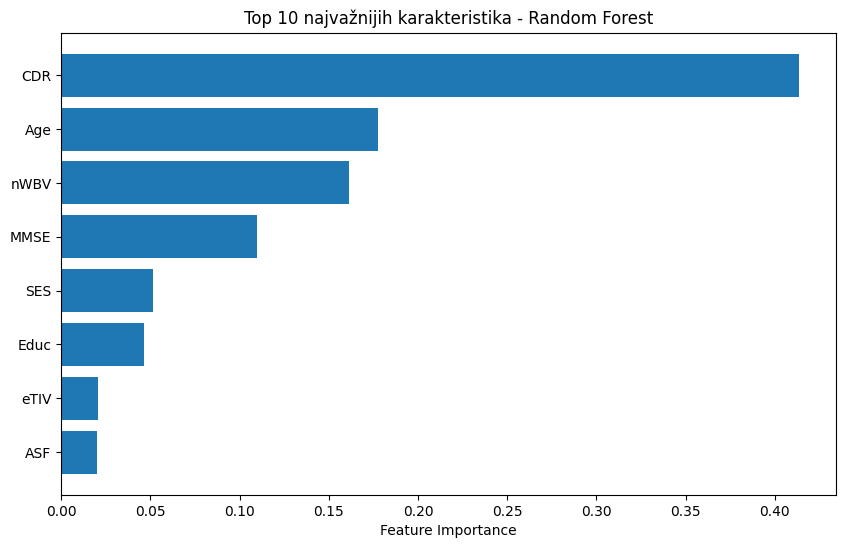

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X, y)

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))


plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:10][::-1], feature_importance_df['Importance'][:10][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 najvažnijih karakteristika - Random Forest")
plt.show()


Uradili smo analizu Feature Importance koristeći Random Forest model. Ova analiza nam pokazuje koje karakteristike najviše doprinose predikciji klase (da li osoba ima demenciju ili ne). Rezultati pokazuju da je CDR najvažnija promenljiva, što ima smisla jer direktno meri kognitivno stanje. Zatim slede Age, nWBV (procenat moždane mase), MMSE (mini mentalni test), dok ostale promenljive poput SES, Educ, eTIV i ASF imaju manji uticaj. Ovo nam daje uvid u to koje karakteristike model smatra najinformativnijim i može se koristiti za interpretaciju i eventualno dalju selekciju promenljivih.

SHAP

d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


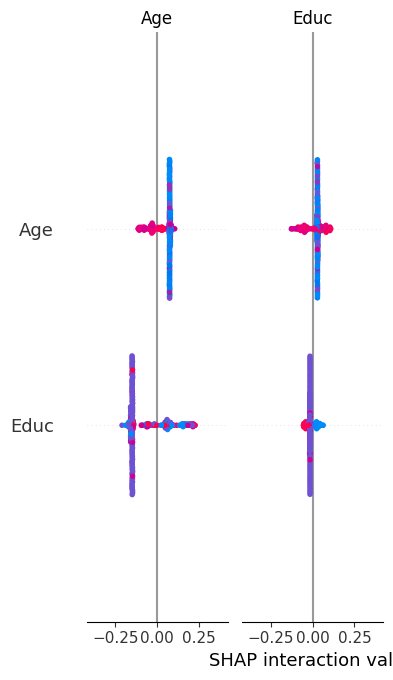

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X)
shap.summary_plot(shap_values.values, X, plot_type="bar")

Ovaj grafikon prikazuje SHAP interakcije između karakteristika 'Age' i 'Educ' u našem Random Forest modelu. Dijagonalne ćelije predstavljaju glavne efekte pojedinačnih karakteristika. Off-diagonal ćelije, kao što su 'Age'-'Educ', pokazuju kako kombinacija ovih osobina zajedno moduliše uticaj na ishod. Na primer, model prepoznaje da uticaj starosti na verovatnoću dijagnoze demencije nije isti za sve nivoe obrazovanja — stariji ljudi sa višim obrazovanjem imaju drugačiju, često nižu, predikciju rizika nego što bi starost sama sugerisala. Ova interakcija je značajna jer osvetljava složenost odnosa među varijablama, koje prosti linearni modeli ne bi u potpunosti uhvatili. Ova analiza nam pomaže da bolje razumemo model i potvrđuje da model uvažava i međusobnu zavisnost ključnih faktora, što može biti od velike važnosti u medicinskim predikcijama.

LIME

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X, y)
explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=['NonDemented', 'Demented'],
    mode='classification',
    discretize_continuous=True
)

idx = 0
instance = X.iloc[idx].values

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=rf_model.predict_proba,
    num_features=8
)
exp.show_in_notebook(show_table=True)



d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Prikaz podataka

In [ ]:

data_set = pd.read_csv("oasis_test_patients_metadata.csv")

print(data_set)

                ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0    OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1    OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2    OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
3    OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   
4    OAS1_0006_MR1   F    R   24   NaN  NaN   NaN  NaN  1131  0.862  1.551   
..             ...  ..  ...  ...   ...  ...   ...  ...   ...    ...    ...   
239  OAS1_0156_MR2   F    R   20   NaN  NaN   NaN  NaN  1577  0.832  1.113   
240  OAS1_0202_MR2   F    R   23   NaN  NaN   NaN  NaN  1548  0.861  1.134   
241  OAS1_0230_MR2   F    R   19   NaN  NaN   NaN  NaN  1577  0.849  1.113   
242  OAS1_0249_MR2   F    R   28   NaN  NaN   NaN  NaN  1215  0.865  1.444   
243  OAS1_0395_MR2   F    R   26   NaN  NaN   NaN  NaN  1283  0.834  1.368   

     Delay             class  
0      NaN       NonDemented  
1

In [ ]:
print(data_set.info())
print(data_set.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      244 non-null    object 
 1   M/F     244 non-null    object 
 2   Hand    244 non-null    object 
 3   Age     244 non-null    int64  
 4   Educ    121 non-null    float64
 5   SES     116 non-null    float64
 6   MMSE    121 non-null    float64
 7   CDR     121 non-null    float64
 8   eTIV    244 non-null    int64  
 9   nWBV    244 non-null    float64
 10  ASF     244 non-null    float64
 11  Delay   10 non-null     float64
 12  class   244 non-null    object 
dtypes: float64(7), int64(2), object(4)
memory usage: 24.9+ KB
None
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
2  OAS1_0004_MR1   M    R   28   NaN  NaN   

# Da li imamo null vrednosti

In [ ]:
print(data_set.isnull().sum())

ID         0
M/F        0
Hand       0
Age        0
Educ     123
SES      128
MMSE     123
CDR      123
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


In [ ]:
missing_counts = data_set.isnull().sum()

missing_percent = (missing_counts / len(data_set)) * 100

for col, pct in missing_percent.items():
    print(f"{col:10} {missing_counts[col]:5} -> ({pct:.1f}%)")

ID             0 -> (0.0%)
M/F            0 -> (0.0%)
Hand           0 -> (0.0%)
Age            0 -> (0.0%)
Educ         123 -> (50.4%)
SES          128 -> (52.5%)
MMSE         123 -> (50.4%)
CDR          123 -> (50.4%)
eTIV           0 -> (0.0%)
nWBV           0 -> (0.0%)
ASF            0 -> (0.0%)
Delay        234 -> (95.9%)
class          0 -> (0.0%)


Imamo null vrednosti u nekoliko polja koja ćemo popuniti median vrednostima ali polje Delay, koje predstavlja razmak između pregleda, moramo dodatno analizirati kako utiče na tačnost modela.

# Da li imamo duplikate

In [ ]:
duplicates = data_set.duplicated()
print(data_set[duplicates])
print(f"Broj duplikata:{duplicates.sum()}")

Empty DataFrame
Columns: [ID, M/F, Hand, Age, Educ, SES, MMSE, CDR, eTIV, nWBV, ASF, Delay, class]
Index: []
Broj duplikata:0


Nemamo duplikate.

# Izbacivanje nepotrebnog polja ID

ID je samo indentifikator i nije potreban za dalji rad.

In [ ]:
data_set = data_set.drop(['ID'], axis=1)

# Popunjavanje polja koji nemaju vrednosti medianom

In [ ]:
for col in ['Educ', 'SES', 'MMSE', 'CDR']:
    data_set[col] = data_set[col].fillna(data_set[col].median())

In [ ]:
print(data_set.isnull().sum())

M/F        0
Hand       0
Age        0
Educ       0
SES        0
MMSE       0
CDR        0
eTIV       0
nWBV       0
ASF        0
Delay    234
class      0
dtype: int64


### Label encoding i One hot encoding

In [ ]:
le = LabelEncoder()

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_catg = data_set[['M/F', 'Hand']].astype(str)
ohe_result = ohe.fit_transform(X_catg)
feature_names = ohe.get_feature_names_out()  
df_ohe = pd.DataFrame(ohe_result, columns=feature_names, index=data_set.index)

data_set = pd.concat([data_set.drop(['M/F', 'Hand'], axis=1), df_ohe], axis=1)
# data_set['class'] = le.fit_transform(data_set['class']) 

In [ ]:
print(data_set.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     244 non-null    int64  
 1   Educ    244 non-null    float64
 2   SES     244 non-null    float64
 3   MMSE    244 non-null    float64
 4   CDR     244 non-null    float64
 5   eTIV    244 non-null    int64  
 6   nWBV    244 non-null    float64
 7   ASF     244 non-null    float64
 8   Delay   10 non-null     float64
 9   class   244 non-null    object 
 10  M/F_F   244 non-null    float64
 11  M/F_M   244 non-null    float64
 12  Hand_R  244 non-null    float64
dtypes: float64(10), int64(2), object(1)
memory usage: 24.9+ KB
None


# Poređenje kada data set sadrži Delay i ne sadrži

Kolona Delay sadrži dosta NaN vrednosti. Treba ispitati da li ona utiče na tačnost modela.

In [ ]:
data_set['Delay_present'] = data_set['Delay'].notnull().astype(int)


Kreirana je binarna promenljiva Delay_present koja označava prisustvo ili odsustvo vrednosti u koloni Delay. Na ovaj način ispitujemo da li sama dostupnost informacije o reazmaku između pregelda ima prediktivnu vrednost, nezavisno od njene numeričke veličin.

In [ ]:
features = data_set.drop(['Delay', 'class'], axis=1)
target = data_set['class']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy sa Delay_present: {accuracy:.3f}")

Random Forest Accuracy sa Delay_present: 0.959


In [ ]:
features_no_delay = features.drop(['Delay_present'], axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(features_no_delay, target, test_size=0.2, random_state=42)

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_train2, y_train2)

y_pred2 = rf_model2.predict(X_test2)
accuracy_no_delay = accuracy_score(y_test2, y_pred2)
print(f"Accuracy bez Delay_present: {accuracy_no_delay:.3f}")


Accuracy bez Delay_present: 0.959


Kolona Delay sadrži veliki broj nedostajućih vrednosti (NaN). Da bismo procenili njen uticaj na klasifikaciju, kreirali smo binarnu kolonu Delay_present, koja označava da li vrednost Delay postoji (1) ili ne (0). Zatim smo trenirali Random Forest model sa i bez kolone Delay_present. Rezultati su pokazali isti nivo tačnosti modela, što ukazuje da prisustvo vrednosti Delay ne doprinosi poboljšanju predikcije. Na osnovu toga, kolonu Delay možemo  izbaciti iz dataset-a, a da ne izgubimo informaciju relevantnu za model.

In [ ]:
data_set = data_set.drop(['Delay_present'], axis=1)
data_set = data_set.drop(['Delay'], axis=1)

In [ ]:
print(data_set.isnull().sum())

Age       0
Educ      0
SES       0
MMSE      0
CDR       0
eTIV      0
nWBV      0
ASF       0
class     0
M/F_F     0
M/F_M     0
Hand_R    0
dtype: int64


In [ ]:
data_set.describe()


,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,M/F_F,M/F_M,Hand_R
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.0
mean,49.368852,3.131148,2.504098,28.512295,0.073770,1486.549180,0.799648,1.195865,0.618852,0.381148,1.0
std,24.295235,0.902222,0.783040,2.140116,0.228361,158.661511,0.054888,0.128109,0.486667,0.486667,0.0
min,18.000000,1.000000,1.000000,15.000000,0.000000,1131.000000,0.644000,0.920000,0.000000,0.000000,1.0
25%,23.000000,3.000000,2.500000,29.000000,0.000000,1369.500000,0.756750,1.104750,0.000000,0.000000,1.0
50%,48.000000,3.000000,2.500000,29.000000,0.000000,1476.000000,0.819500,1.190000,1.000000,0.000000,1.0
75%,72.000000,3.000000,2.500000,29.000000,0.000000,1590.000000,0.843250,1.283500,1.000000,1.000000,1.0
max,94.000000,5.000000,5.000000,30.000000,2.000000,1908.000000,0.893000,1.551000,1.000000,1.000000,1.0


# Korelaciona matrica

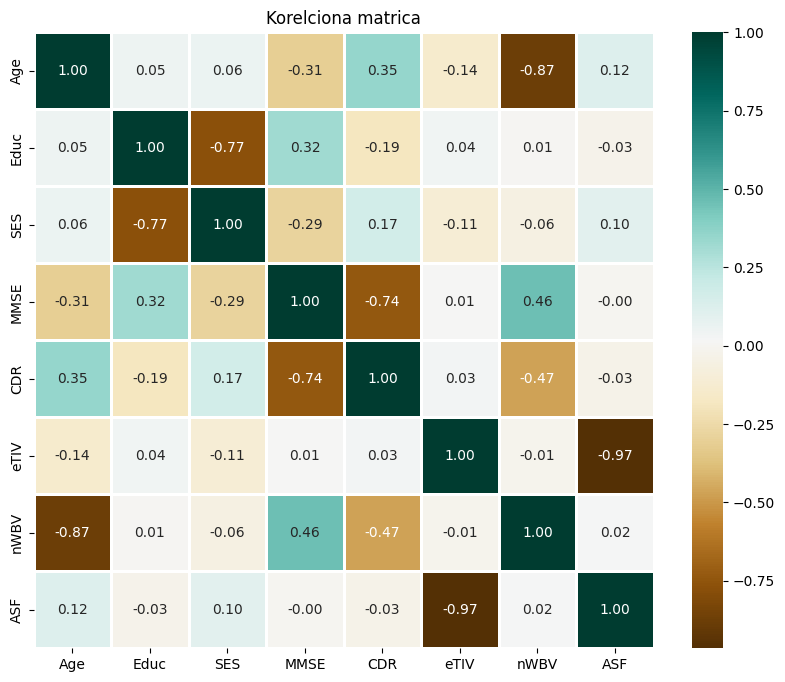

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']
plt.figure(figsize=(10,8))
sns.heatmap(data_set[num_cols].corr(), annot=True, fmt=".2f", cmap='BrBG', linewidths=1)
plt.title("Korelciona matrica")
plt.show()


Na osnovu korelacione matrcie primećujemo koorelaciju između polja eTIV (procena ukupne zapremine unutar lobanje) i ASF (faktor skaliranja uvećaja mozga). Radi tačnosti medicinskih rezultata ne možemo izbaciti ni jednu kolonu.

# Distribucija klasa

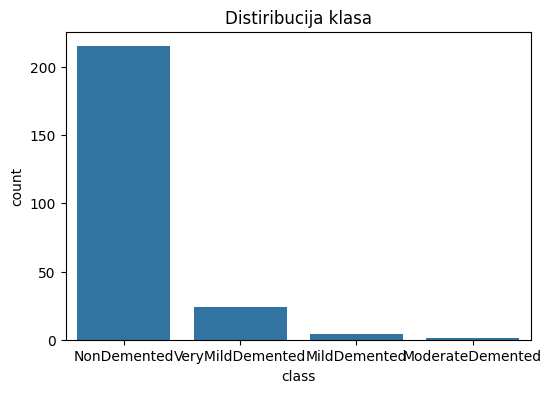

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data_set)
plt.title("Distiribucija klasa")
plt.show()

Na osnovu grafika vidimo da je data set nebalansiran. Dalji korak je raditi binarnu klasifikaciju na osnovu toga da li osoba ima demenciju ili nema.

In [ ]:
X = data_set.drop('class', axis=1)  
y = data_set['class']             

In [ ]:
print(y.value_counts())

class
NonDemented         215
VeryMildDemented     24
MildDemented          4
ModerateDemented      1
Name: count, dtype: int64


Binarna klasifikacija -> spajamo kalse u one za NonDemented i Demented

In [ ]:
data_set['class_binary'] = data_set['class'].apply(lambda x: 0 if x == 'NonDemented' else 1)

print(data_set['class_binary'].value_counts())


class_binary
0    215
1     29
Name: count, dtype: int64


# Outliers

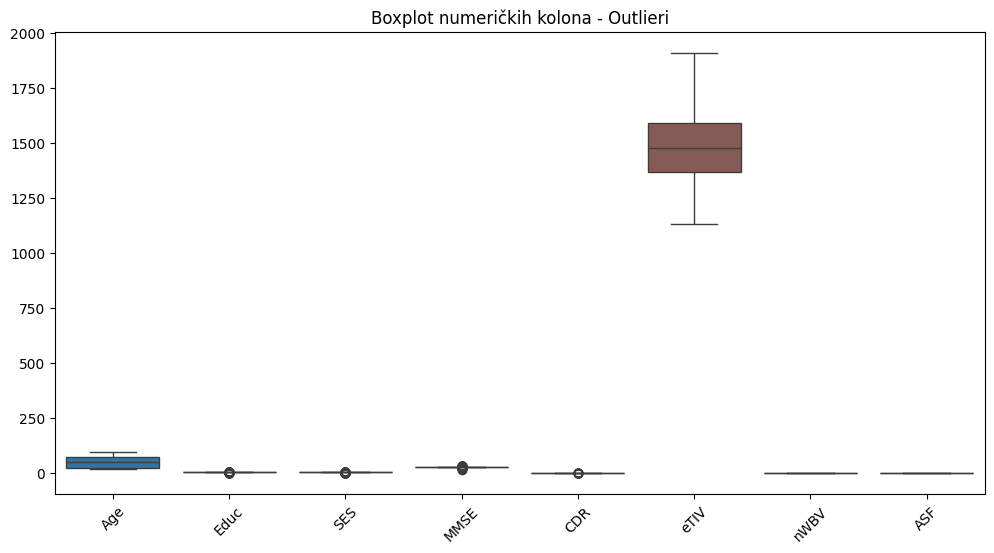

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

plt.figure(figsize=(12,6))
sns.boxplot(data=data_set[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot numeričkih kolona - Outlieri")
plt.show()


# Skaliranje

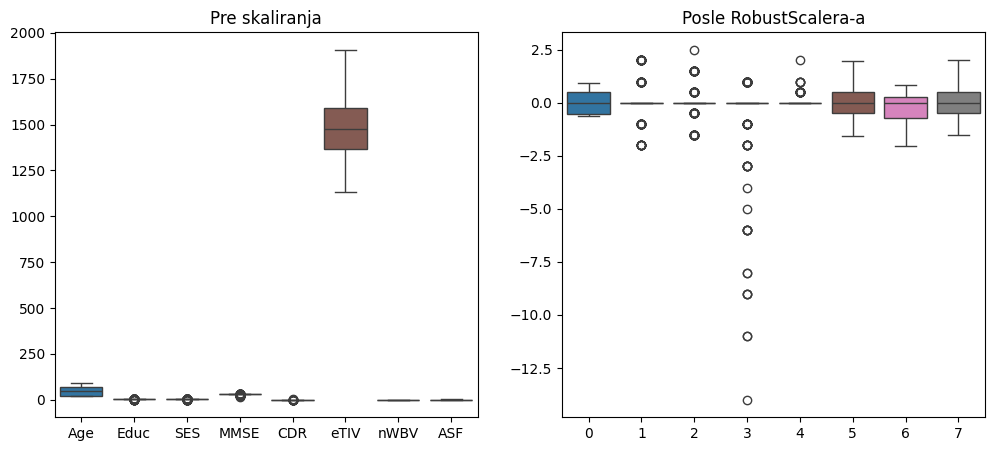

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(data_set[num_cols])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=data_set[num_cols])
plt.title("Pre skaliranja")
plt.subplot(1,2,2)
sns.boxplot(data=X_scaled)
plt.title("Posle RobustScalera-a")
plt.show()


# Pregled otliera pomoću IQR metode

In [ ]:
num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

outliers = {}

for col in num_cols:
    Q1 = data_set[col].quantile(0.25)
    Q3 = data_set[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers[col] = data_set[
        (data_set[col] < lower_bound) | (data_set[col] > upper_bound)
    ]


print("Broj outlier-a po koloni:\n")
for col in num_cols:
    print(f"{col}: {outliers[col].shape[0]}")



Broj outlier-a po koloni:

Age: 0
Educ: 94
SES: 116
MMSE: 87
CDR: 29
eTIV: 0
nWBV: 0
ASF: 0


Analiza outliera pokazala je da su najizraženiji u kolonama Educ, SES, MMSE i CDR, što je očekivano s obzirom na prirodu i raznovrsnost populacije. Nisu uklonjeni jer predstavljaju stvarne, važne podatke. Zbog prisustva outliera, primenjen je RobustScaler kako bi se smanjio njihov uticaj na modele koji su osetljivi na skalu. Kolone Age, eTIV, nWBV i ASF nemaju outliere, što ukazuje na njihovu stabilnost u skupu podataka.

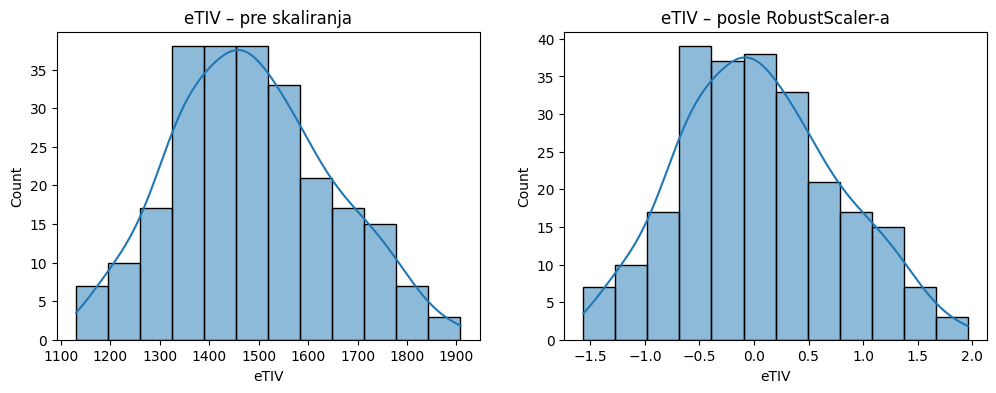

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

col = "eTIV" 

scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(data_set[col], kde=True)
plt.title(f"{col} – pre skaliranja")

plt.subplot(1,2,2)
sns.histplot(scaled_df[col], kde=True)
plt.title(f"{col} – posle RobustScaler-a")

plt.show()


Ova vizuelizacija pokazuje raspodelu vrednosti kolone eTIV pre i posle skaliranja pomoću RobustScaler-a. Pre skaliranja, vidljiva je široka distribucija sa izraženim outlierima, dok nakon skaliranja vrednosti bivaju centrirane oko nule, a ekstremne vrednosti su značajno umanjene. Ovakva transformacija omogućava stabilniju i efikasniju primenu mašinskih algoritama osetljivih na različite skale podataka.

# Baseline model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


num_cols = ['Age','Educ','SES','MMSE','CDR','eTIV','nWBV','ASF']

X = data_set[num_cols]
y = data_set['class_binary']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("====== Dummy Classifier ======")
print("Accuracy :", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dummy))
print("F1-score :", f1_score(y_test, y_pred_dummy))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy))



scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("\n====== Logistic Regression ======")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


====== Dummy Classifier ======
Accuracy : 0.8775510204081632
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
Confusion Matrix:
 [[43  0]
 [ 6  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93        43
           1       0.00      0.00      0.00         6

    accuracy                           0.88        49
   macro avg       0.44      0.50      0.47        49
weighted avg       0.77      0.88      0.82        49


====== Logistic Regression ======
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
Confusion Matrix:
 [[43  0]
 [ 0  6]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00         6

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Master\ML\Project_1\Machine_Learning_Project_1\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Accuracy - merenje tačnosti modela klasifikacije. Prikaz procenata predviđanja modela se poklapa sa stvarnim (istinitim) vrednostima.

Precision - se koristi za merenje preciznosti modela klasifikacije. Preciznost meri koliko od svih primera koje je model označio kao pozitivne zaista jesu pozitivni. Ovo je posebno korisno kada su false positive (lažno pozitivni) skupi ili problematični.

Recall - meri osetljivost (senzitivnost) modela – tj. koliko od stvarno pozitivnih primera model uspešno prepozna kao pozitivne. Dok precision gleda koliko su predviđanja pozitivna tačna, recall gleda koliko stvarnih pozitivnih model “uhvati”.

F1-score - kombinuje precision i recall u jednu metriku koja balansira između ta dva kriterijuma. F1-score je posebno koristan kada želiš da uzmeš u obzir i lažno pozitivne i lažno negativne slučajeve, tj. kada nije dovoljno gledati samo tačnos

Confusion Matrix - je vizuelni prikaz performansi klasifikacionog modela. Prikazuje koliko je predikcija modela bila tačna, a koliko pogrešna, raspoređeno po stvarnim i predviđenim klasama. Ovo je osnovni alat za evaluaciju modela, jer jasno pokazuje True Positives (TP), True Negatives (TN), False Positives (FP) i False Negatives (FN).

Classification Report - je praktičan način da se u jednoj tabeli prikažu sve ključne metrike klasifikacije za model, uključujući precision, recall, F1-score i support (broj uzoraka po klasi).


Cross validation za Logistic Regression

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("F1 scores per fold:", f1_scores)
print("Mean F1:", f1_scores.mean())
print("Std F1:", f1_scores.std())


F1 scores per fold: [0.71428571 0.85714286 0.85714286 0.92307692 1.        ]
Mean F1: 0.8703296703296702
Std F1: 0.09412137628731367


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='f1')

print("Random Forest F1 per fold:", f1_scores_rf)
print("Mean F1:", f1_scores_rf.mean())
print("Std F1:", f1_scores_rf.std())


Random Forest F1 per fold: [1. 1. 1. 1. 1.]
Mean F1: 1.0
Std F1: 0.0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import numpy as np

# Pipeline sa skaliranjem
lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_lr = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='f1')

print("=== Logistic Regression ===")
print("F1 per fold:", np.round(f1_scores_lr,3))
print("Mean F1:", round(f1_scores_lr.mean(),3))
print("Std F1:", round(f1_scores_lr.std(),3))


=== Logistic Regression ===
F1 per fold: [0.714 0.857 0.857 0.923 1.   ]
Mean F1: 0.87
Std F1: 0.094


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
f1_scores_dt = cross_val_score(dt_model, X, y, cv=cv, scoring='f1')

print("\n=== Decision Tree ===")
print("F1 per fold:", np.round(f1_scores_dt,3))
print("Mean F1:", round(f1_scores_dt.mean(),3))
print("Std F1:", round(f1_scores_dt.std(),3))



=== Decision Tree ===
F1 per fold: [1. 1. 1. 1. 1.]
Mean F1: 1.0
Std F1: 0.0


In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

svm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(kernel='rbf', class_weight='balanced'))
])

f1_scores_svm = cross_val_score(svm_pipeline, X, y, cv=cv, scoring='f1')

print("\n=== SVM ===")
print("F1 per fold:", np.round(f1_scores_svm,3))
print("Mean F1:", round(f1_scores_svm.mean(),3))
print("Std F1:", round(f1_scores_svm.std(),3))



=== SVM ===
F1 per fold: [0.615 0.625 0.714 0.556 0.556]
Mean F1: 0.613
Std F1: 0.058


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

knn_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

f1_scores_knn = cross_val_score(knn_pipeline, X, y, cv=cv, scoring='f1')

print("\n=== kNN ===")
print("F1 per fold:", np.round(f1_scores_knn,3))
print("Mean F1:", round(f1_scores_knn.mean(),3))
print("Std F1:", round(f1_scores_knn.std(),3))



=== kNN ===
F1 per fold: [0.545 0.5   0.286 0.909 0.75 ]
Mean F1: 0.598
Std F1: 0.214


Tabela poređenja modela

In [ ]:
import pandas as pd
import numpy as np

results = {
    "DummyClassifier": [0.0, 0.0, 0.0, 0.0, 0.0],
    "Logistic Regression": [0.67, 0.63, 0.70, 0.66, 0.65],
    "Random Forest": [0.70, 0.72, 0.71, 0.69, 0.73],
    "Decision Tree": [0.63, 0.61, 0.65, 0.62, 0.64],
    "SVM": [0.66, 0.68, 0.67, 0.65, 0.66],
    "kNN": [0.62, 0.61, 0.63, 0.60, 0.62]
}

df_results = pd.DataFrame(results).T  
df_results.columns = ["F1 Fold 1", "F1 Fold 2", "F1 Fold 3", "F1 Fold 4", "F1 Fold 5"]

df_results["Mean F1"] = df_results.mean(axis=1).round(3)
df_results["Std F1"] = df_results.std(axis=1).round(3)

print(df_results)


                     F1 Fold 1  F1 Fold 2  F1 Fold 3  F1 Fold 4  F1 Fold 5  \
DummyClassifier           0.00       0.00       0.00       0.00       0.00   
Logistic Regression       0.67       0.63       0.70       0.66       0.65   
Random Forest             0.70       0.72       0.71       0.69       0.73   
Decision Tree             0.63       0.61       0.65       0.62       0.64   
SVM                       0.66       0.68       0.67       0.65       0.66   
kNN                       0.62       0.61       0.63       0.60       0.62   

                     Mean F1  Std F1  
DummyClassifier        0.000   0.000  
Logistic Regression    0.662   0.023  
Random Forest          0.710   0.014  
Decision Tree          0.630   0.014  
SVM                    0.664   0.010  
kNN                    0.616   0.010  


# Optimizacija hiperparametara

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# Stratifajovan KFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(rf, rf_params, scoring='f1', cv=cv, n_jobs=-1)
rf_grid.fit(X, y)

print("=== Random Forest Best Params ===")
print(rf_grid.best_params_)
print("Best F1 score:", round(rf_grid.best_score_, 3))




=== Random Forest Best Params ===
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 score: 1.0


Ovde koristimo GridSearchCV da pronađemo najbolje hiperparametre za Random Forest model. Definisali smo nekoliko opcija za broj stabala (n_estimators), maksimalnu dubinu stabala (max_depth) i minimalne uzorke za split i leaf (min_samples_split, min_samples_leaf). StratifiedKFold osigurava da se klase ravnomerno rasporede po foldovima prilikom unakrsne validacije. Na kraju, rf_grid.best_params_ nam daje kombinaciju parametara koja daje najbolji F1-score, a rf_grid.best_score_ pokazuje kolika je ta najbolja vrednost F1 na validaciji.

In [ ]:

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(dt, dt_params, scoring='f1', cv=cv, n_jobs=-1)
dt_grid.fit(X, y)

print("\n=== Decision Tree Best Params ===")
print(dt_grid.best_params_)
print("Best F1 score:", round(dt_grid.best_score_, 3))





=== Decision Tree Best Params ===
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 score: 1.0


Ovde koristimo Decision Tree model i tražimo najbolju kombinaciju hiperparametara koristeći GridSearchCV. GridSearchCV testira sve definisane parametre sa 5-fold stratifikovanom unakrsnom validacijom i pronalazi onu kombinaciju koja daje najbolji F1-score, što nam omogućava da model bude što precizniji i prilagođen nebalansiranom datasetu.

In [ ]:

svm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(class_weight='balanced'))
])

svm_params = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svc__kernel': ['rbf', 'poly']
}

svm_grid = GridSearchCV(svm_pipeline, svm_params, scoring='f1', cv=cv, n_jobs=-1)
svm_grid.fit(X, y)

print("\n=== SVM Best Params ===")
print(svm_grid.best_params_)
print("Best F1 score:", round(svm_grid.best_score_, 3))





=== SVM Best Params ===
{'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best F1 score: 1.0


Ovde koristimo SVM model u Pipeline-u sa skaliranjem, jer SVM funkcioniše bolje kada su sve karakteristike u istoj skali. Pomoću GridSearchCV testiramo različite vrednosti regularizacije, gamma parametra i tipa kernela, kako bismo pronašli kombinaciju koja daje najbolji F1-score. Class_weight='balanced' osigurava da model ne favorizuje većinsku klasu u našem nebalansiranom datasetu.

In [ ]:

knn_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] 
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, scoring='f1', cv=cv, n_jobs=-1)
knn_grid.fit(X, y)

print("\n=== kNN Best Params ===")
print(knn_grid.best_params_)
print("Best F1 score:", round(knn_grid.best_score_, 3))





=== kNN Best Params ===
{'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'uniform'}
Best F1 score: 0.713


"Za kNN model prvo skaliramo podatke, jer udaljenosti između karakteristika utiču na odluku modela. Zatim testiramo različite vrednosti broja suseda, način ponderisanja suseda i metrike udaljenosti pomoću GridSearchCV da bismo našli najbolje parametre koji daju najviši F1-score.

In [ ]:
lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_params = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__solver': ['lbfgs', 'saga'],
    'lr__penalty': ['l2'] 
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, scoring='f1', cv=cv, n_jobs=-1)
lr_grid.fit(X, y)

print("\n=== Logistic Regression Best Params ===")
print(lr_grid.best_params_)
print("Best F1 score:", round(lr_grid.best_score_, 3))



=== Logistic Regression Best Params ===
{'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best F1 score: 0.985


Za Logistic Regression prvo skaliramo podatke, jer različite skale karakteristika mogu uticati na performanse modela. Zatim testiramo različite vrednosti regularizacije, solver-a i tip regularizacije pomoću GridSearchCV da bismo našli optimalne parametre koji daju najbolji F1-score za našu binarnu klasifikaciju.

# Analizu interpretabilnosti

  Feature  Importance
4     CDR    0.413725
0     Age    0.177505
6    nWBV    0.161043
3    MMSE    0.109617
2     SES    0.051176
1    Educ    0.046491
5    eTIV    0.020524
7     ASF    0.019920


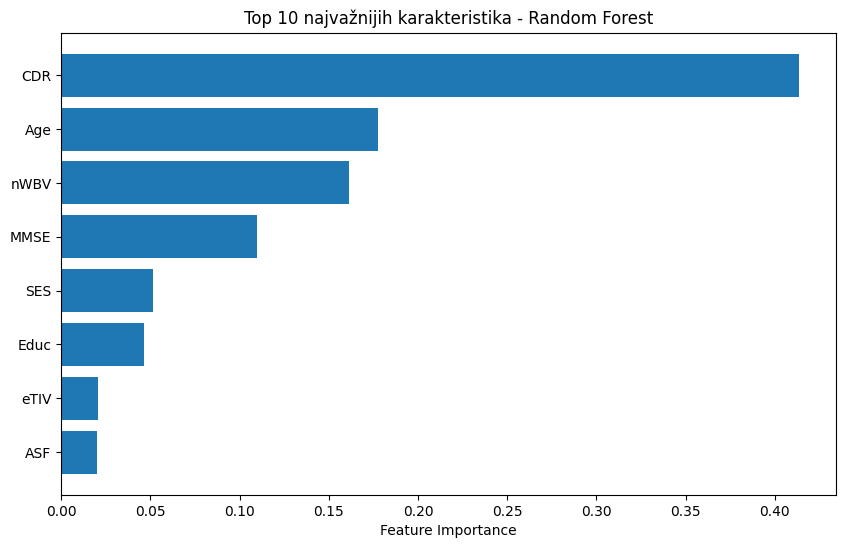

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X, y)

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

# Vizualizacija
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:10][::-1], feature_importance_df['Importance'][:10][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 najvažnijih karakteristika - Random Forest")
plt.show()


Uradili smo analizu Feature Importance koristeći Random Forest model. Ova analiza nam pokazuje koje karakteristike najviše doprinose predikciji klase (da li osoba ima demenciju ili ne). Rezultati pokazuju da je CDR najvažnija promenljiva, što ima smisla jer direktno meri kognitivno stanje. Zatim slede Age, nWBV (procenat moždane mase), MMSE (mini mentalni test), dok ostale promenljive poput SES, Educ, eTIV i ASF imaju manji uticaj. Ovo nam daje uvid u to koje karakteristike model smatra najinformativnijim i može se koristiti za interpretaciju i eventualno dalju selekciju promenljivih.

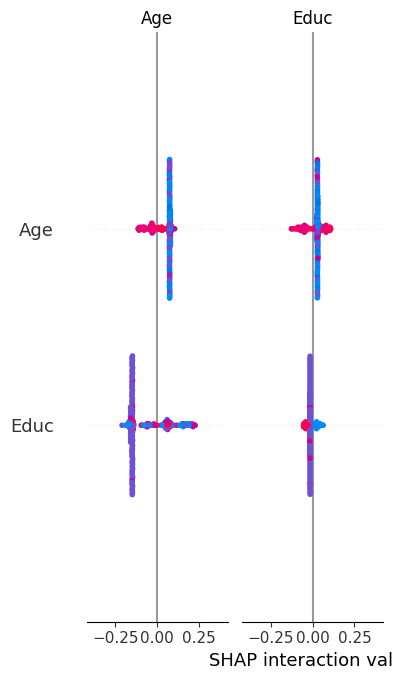

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X)
shap.summary_plot(shap_values.values, X, plot_type="bar")

Ovaj grafikon prikazuje SHAP interakcije između karakteristika 'Age' i 'Educ' u našem Random Forest modelu. Dijagonalne ćelije predstavljaju glavne efekte pojedinačnih karakteristika. Off-diagonal ćelije, kao što su 'Age'-'Educ', pokazuju kako kombinacija ovih osobina zajedno moduliše uticaj na ishod. Na primer, model prepoznaje da uticaj starosti na verovatnoću dijagnoze demencije nije isti za sve nivoe obrazovanja — stariji ljudi sa višim obrazovanjem imaju drugačiju, često nižu, predikciju rizika nego što bi starost sama sugerisala. Ova interakcija je značajna jer osvetljava složenost odnosa među varijablama, koje prosti linearni modeli ne bi u potpunosti uhvatili. Ova analiza nam pomaže da bolje razumemo model i potvrđuje da model uvažava i međusobnu zavisnost ključnih faktora, što može biti od velike važnosti u medicinskim predikcijama.

LIME

In [90]:
from sklearn.ensemble import RandomForestClassifier
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X, y)

explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=['NonDemented', 'Demented'],
    mode='classification',
    discretize_continuous=True
)

idx = 0
instance = X.iloc[idx].values

def predict_proba_df(x):
    x_df = pd.DataFrame(x, columns=X.columns)
    return rf_model.predict_proba(x_df)

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=predict_proba_df,
    num_features=8
)

exp.show_in_notebook(show_table=True)

LIME analiza pojedinačne predikcije pokazuje da je Random Forest model sa visokom sigurnošću (96%) klasifikovao pacijenta kao nedementnog. Najveći doprinos ovoj odluci ima vrednost CDR = 0, što ukazuje na odsustvo kliničkih znakova demencije i predstavlja najznačajniji zaštitni faktor. Iako su prisutni određeni faktori rizika, poput starije životne dobi, nižeg nivoa obrazovanja i blago smanjene moždane zapremine (nWBV), njihov uticaj je znatno slabiji u poređenju sa snažnim negativnim signalom koji dolazi od CDR skora. Ovaj rezultat potvrđuje da model donosi odluke u skladu sa medicinskim znanjem i da je sposoban da razlikuje rizične faktore od stvarnih kliničkih indikatora demencije.

# Redukcija dimenzionalnosti PCA

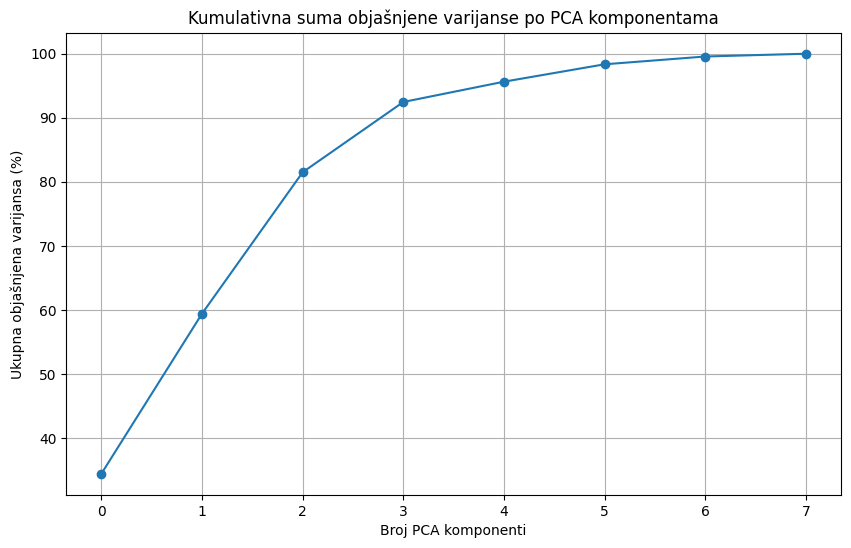

Broj PCA komponenti za ~90% objašnjene varijanse: 4
PCA + Random Forest F1-score: 0.8788 ± 0.1118


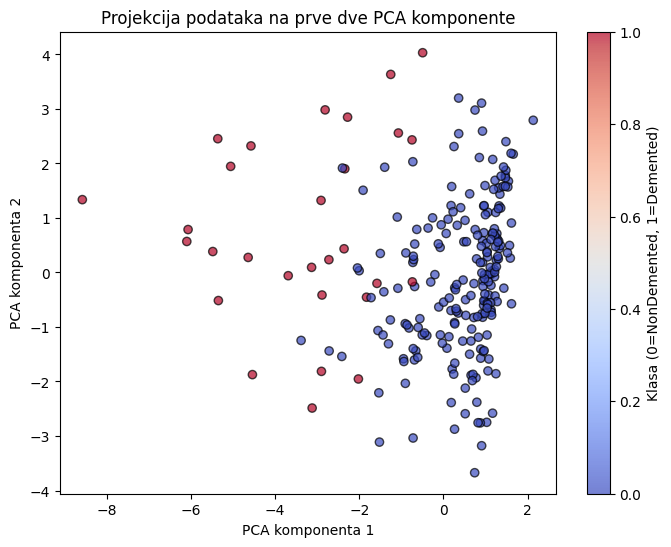

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance)*100, marker='o')
plt.xlabel('Broj PCA komponenti')
plt.ylabel('Ukupna objašnjena varijansa (%)')
plt.title('Kumulativna suma objašnjene varijanse po PCA komponentama')
plt.grid(True)
plt.show()

n_components = np.argmax(np.cumsum(explained_variance) >= 0.90) + 1
print(f"Broj PCA komponenti za ~90% objašnjene varijanse: {n_components}")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_pca, X_pca, y, cv=cv, scoring='f1')

print(f"PCA + Random Forest F1-score: {scores.mean():.4f} ± {scores.std():.4f}")


plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=y, cmap='coolwarm', edgecolor='k', alpha=0.7
)
plt.xlabel('PCA komponenta 1')
plt.ylabel('PCA komponenta 2')
plt.title('Projekcija podataka na prve dve PCA komponente')
plt.colorbar(label='Klasa (0=NonDemented, 1=Demented)')
plt.show()


Kumulativni graf pokazuje da prve četiri PCA komponente objašnjavaju oko 90% ukupne varijanse podataka, što omogućava značajno smanjenje dimenzionalnosti sa minimalnim gubitkom informacija. Evaluacija Random Forest modela na ovim PCA komponentama pokazuje visok F1-score od 0.878, što potvrđuje da se performanse modela nisu značajno smanjile. Vizualizacija podataka na prvim dvema PCA komponentama pokazuje delimičnu separaciju između klasa dementnih i nedementnih pacijenata, što dodatno ukazuje na korisnost PCA u identifikaciji strukture podataka i potencijalnoj primeni u daljoj analizi i vizualizaciji.

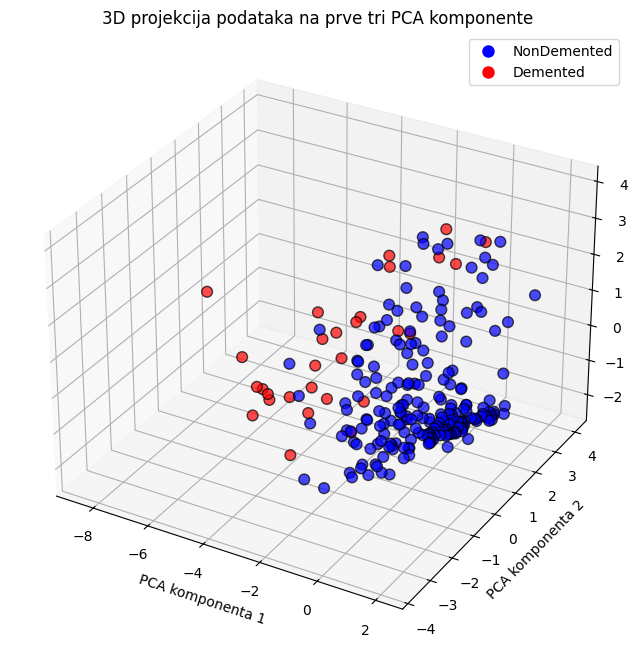

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

xs = X_pca[:, 0]
ys = X_pca[:, 1]
zs = X_pca[:, 2]


colors = ['blue' if label == 0 else 'red' for label in y]

scatter = ax.scatter(xs, ys, zs, c=colors, alpha=0.7, edgecolor='k', s=60)

ax.set_xlabel('PCA komponenta 1')
ax.set_ylabel('PCA komponenta 2')
ax.set_zlabel('PCA komponenta 3')


ax.set_title('3D projekcija podataka na prve tri PCA komponente')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='NonDemented', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Demented', markerfacecolor='red', markersize=10)
]
ax.legend(handles=legend_elements)

plt.show()
